# Week 2 Excercises

In [1]:
import sys, pathlib
repo_root = pathlib.Path.cwd().parents[1]
sys.path.append(str(repo_root / "src"))

## Problem 1

1. 

$$
c_1(x) = x_1 + x_3 - 3 = 0
$$

$$
c_2(x) = x_2 + x_3 = 0
$$

2. 

$$
\mathcal{L}(x, \lambda) = \bold{x}^T A \bold{x} + \bold{b}^T \bold{x} - \lambda_1 c_1(\bold{x}) - \lambda_2 c_2(\bold{x})
$$

where 

$$
A = \begin{bmatrix}
3 &  1 & 0.5 \\
1 & 2.5 & 1 \\
0.5 & 1 & 2
\end{bmatrix}
$$
and
$$
\bold{b} = \begin{bmatrix}
-8 \\
-3 \\
-3 
\end{bmatrix}
$$


In [2]:
import sympy as sp 
x1, x2, x3, l1, l2 = sp.symbols('x1 x2 x3 lambda_1 lambda_2') 
x = sp.Matrix([x1, x2, x3]) 


A = sp.Matrix([
    [3, 1, 0.5], 
    [1, 2.5, 1], 
    [0.5, 1, 2]
    ])

b = sp.Matrix([-8, -3, -3])
c1 = x1 + x3 -3 
c2 = x2 + x3

f = x.transpose() * A * x + b.transpose() * x 
f = f[0].expand()  - l1 * c1 - l2 * c2
sp.print_latex(f)

- \lambda_{1} \left(x_{1} + x_{3} - 3\right) - \lambda_{2} \left(x_{2} + x_{3}\right) + 3 x_{1}^{2} + 2 x_{1} x_{2} + 1.0 x_{1} x_{3} - 8 x_{1} + 2.5 x_{2}^{2} + 2 x_{2} x_{3} - 3 x_{2} + 2 x_{3}^{2} - 3 x_{3}


3. 

larange function is: 

$$
\mathcal{L}(x, \lambda) = - \lambda_{1} \left(x_{1} + x_{3} - 3\right) - \lambda_{2} \left(x_{2} + x_{3}\right) + 3 x_{1}^{2} + 2 x_{1} x_{2} + 1.0 x_{1} x_{3} - 8 x_{1} + 2.5 x_{2}^{2} + 2 x_{2} x_{3} - 3 x_{2} + 2 x_{3}^{2} - 3 x_{3}
$$

$$
\nabla \mathcal{L} (x, \lambda) = \left[\begin{matrix}- \lambda_{1} + 6 x_{1} + 2 x_{2} + 1.0 x_{3} - 8\\- \lambda_{2} + 2 x_{1} + 5.0 x_{2} + 2 x_{3} - 3\\- \lambda_{1} - \lambda_{2} + 1.0 x_{1} + 2 x_{2} + 4 x_{3} - 3\end{matrix}\right]
$$

In [3]:
grad_f = sp.Matrix([sp.diff(f, var) for var in x] )
sp.print_latex(grad_f)

\left[\begin{matrix}- \lambda_{1} + 6 x_{1} + 2 x_{2} + 1.0 x_{3} - 8\\- \lambda_{2} + 2 x_{1} + 5.0 x_{2} + 2 x_{3} - 3\\- \lambda_{1} - \lambda_{2} + 1.0 x_{1} + 2 x_{2} + 4 x_{3} - 3\end{matrix}\right]


and when we know that 

$$
c_1(x) = 0
$$

$$
c_2(x) = 0
$$

4. 

In [4]:
e1 = sp.Eq(grad_f[0], 0)
e2 = sp.Eq(grad_f[1], 0)
e3 = sp.Eq(grad_f[2], 0)
e4 = sp.Eq(c1, 0)
e5 = sp.Eq(c2, 0)

solution = sp.solve([e1, e2, e3, e4, e5], (x1, x2, x3, l1, l2))

### 

print("We have the following solution for the optimal point:")
for var, val in solution.items():
    print(f"{var} = {val}") 

We have the following solution for the optimal point:
lambda_1 = 3.00000000000000
lambda_2 = -2.00000000000000
x1 = 2.00000000000000
x2 = -1.00000000000000
x3 = 1.00000000000000


#### Part b

1. 
H is the hessian matrix of the function f\
g is the linear term of f \
A is the coefficeints of the contraints\
b is the RHS of the contraints. 

2. 

$$
\mathcal{L}(x, \lambda) = \frac{1}{2} x^T H x + g^Tx - \lambda^T (Ax - b) 
$$

Same problem, same minimum


4. 
By sufficaient conditions, we know that for all feaseable step direction $h$, this must satisfy

$$
h^T \nabla^2 \mathcal{L}(x^*, \lambda^*) h > 0
$$

where 

$$
\nabla c_i(x^*) h = 0 
$$

for all active constraints

In [5]:
hessian_f = sp.hessian(f, x) 

h1, h2, h3, c= sp.symbols('h1 h2 h3 c')

h = sp.Matrix([h1, h2, h3])

g = h.transpose() * hessian_f * h
g[0].expand() 

6*h1**2 + 4*h1*h2 + 2.0*h1*h3 + 5.0*h2**2 + 4*h2*h3 + 4*h3**2

In [6]:
e1 = sp.Eq(h[0] + c, 0)
e2 = sp.Eq(h[1] + c, 0)
e3 = sp.Eq(h[2] + c, 0) 


solution = sp.solve([e1, e2, e3], (h1, h2, h3, c))
print("We have the following solution for the hessian:")
for var, val in solution.items():
    print(f"{var} = {val}")

We have the following solution for the hessian:
h1 = -c
h2 = -c
h3 = -c


As this is the only solutions, we see that this violates the activate constraints and therefore its a minimum. 

# Problem 2

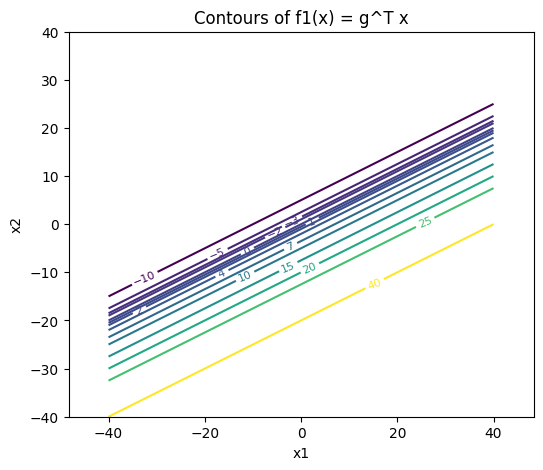

In [7]:
import numpy as np
import matplotlib.pyplot as plt


g = np.array([1, -2])

A = np.array([
    [1, 0, 1, 1, -5],
    [0, 1, -1, -5, 1],
])

b = np.array([0, 0, -2, -20, -15])  # row vector


g = np.array([1, -2])

def f1(x, y):
    return g[0] * x + g[1] * y

# Grid
x = np.linspace(-40, 40, 500)
y = np.linspace(-40, 40, 500)
X, Y = np.meshgrid(x, y)

# Evaluate
Z = f1(X, Y)

# Contour plot
plt.figure(figsize=(6, 5))
levels = np.logspace(0, 3.5, 10)
cs = plt.contour(X, Y, Z, levels=[-10, -5, -3, -2, 0, 1, 2, 4, 7, 10, 15, 20, 25, 40])
plt.clabel(cs, inline=True, fontsize=8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Contours of f1(x) = g^T x')
plt.axis('equal')
plt.show()





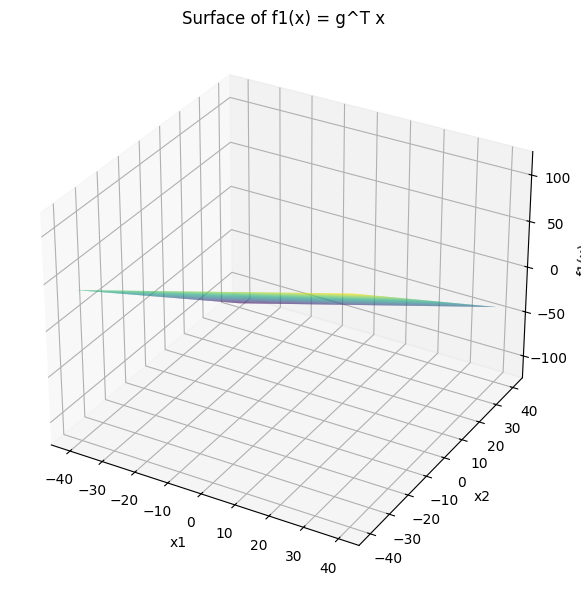

In [8]:
## 3d plot

g = np.array([1, -2])

def f1(x, y):
    return g[0] * x + g[1] * y

# Grid
x = np.linspace(-40, 40, 200)
y = np.linspace(-40, 40, 200)
X, Y = np.meshgrid(x, y)

# Evaluate
Z = f1(X, Y)

# 3D plot
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f1(x)")
ax.set_title("Surface of f1(x) = g^T x")

plt.tight_layout()
plt.show()

2. This must be at (-3,0)

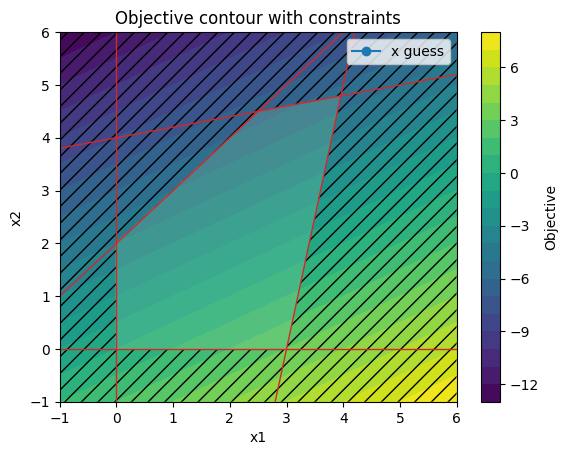

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Objective contour with constraints'}, xlabel='x1', ylabel='x2'>)

In [15]:
from optim.plot import Plotter


coeffs = np.array([1, -2])



def f1(x):

    return coeffs[0] * x[0] + coeffs[1] * x[1]



constraints = [

    lambda x: x[1],

    lambda x: x[0],

    lambda x: x[0] - x[1] + 2,

    lambda x: x[0] - 5 * x[1] + 20,

    lambda x: -5 * x[0] + x[1] + 15,

]  # each <= 0 is feasible



plotter = Plotter(objective=f1, constraints=constraints, x=np.array([-3, 0]))

plotter.plot_contour(
    xlim=(-1, 6),
    ylim=(-1, 6),
    grid_size=400,  # increase if you want smoother contours
)

3. Larange function is: 

$$
\mathcal{L}(x, \lambda) = g'x - \lambda (Ax - b)
$$

First order is: 

In [19]:
# Using sympy to find the optimal point 
x1, x2, l1, l2, l3, l4, l5  = sp.symbols('x1 x2 lambda_1 lambda_2 lambda_3 lambda_4 lambda_5') 
g = sp.Matrix([1, -2]) 
A = sp.Matrix([
    [1, 0],
    [0, 1],
    [1, -1],
    [1, -5],
    [-5, 1]
    ])
b = sp.Matrix([0, 0, -2, -20, -15]) 
x = sp.Matrix([x1, x2])
lam = sp.Matrix([l1, l2, l3, l4, l5])
f = g.transpose() * x -  lam.transpose() * (A * x - b) 
f = f[0].expand() 
grad_f = sp.Matrix([sp.diff(f, var) for var in [x1, x2, l1, l2, l3, l4, l5]] ) 
sp.print_latex(grad_f)

\left[\begin{matrix}- \lambda_{1} - \lambda_{3} - \lambda_{4} + 5 \lambda_{5} + 1\\- \lambda_{2} + \lambda_{3} + 5 \lambda_{4} - \lambda_{5} - 2\\- x_{1}\\- x_{2}\\- x_{1} + x_{2} - 2\\- x_{1} + 5 x_{2} - 20\\5 x_{1} - x_{2} - 15\end{matrix}\right]


$$
\nabla \mathcal{L}(\lambda, x) = \left[\begin{matrix}- \lambda_{1} - \lambda_{3} - \lambda_{4} + 5 \lambda_{5} + 1\\- \lambda_{2} + \lambda_{3} + 5 \lambda_{4} - \lambda_{5} - 2\\- x_{1}\\- x_{2}\\- x_{1} + x_{2} - 2\\- x_{1} + 5 x_{2} - 20\\5 x_{1} - x_{2} - 15\end{matrix}\right] = \bold{0}
$$

where 

$$
\lambda_i = 0 \lor c_i(x) = 0
$$

5. 

We see that there is two active contraints. 

Its: 



$c_3$ and $c_4$

We can now solve it using the activate set

In [23]:

#lambda x: x[0] - x[1] + 2,
#lambda x: x[0] - 5 * x[1] + 20,
f_new = g.transpose() * x 
f_new = f_new[0].expand() -  l1 * (x1 - x2 + 2) - l2 * (x1 - 5 * x2 + 20)
grad_f_new = sp.Matrix([sp.diff(f_new, var) for var in [x1, x2, l1, l2]] )


e1 = sp.Eq(grad_f_new[0], 0)
e2 = sp.Eq(grad_f_new[1], 0)
e3 = sp.Eq(grad_f_new[2], 0)
e4 = sp.Eq(grad_f_new[3], 0)
e5 = sp.Eq(x[0] - x[1] + 2, 0)
e6 = sp.Eq(x[0] - 5 * x[1] + 20, 0)


sol = sp.solve([e1, e2, e3, e4, e5, e6], (x1, x2, l1, l2))
print("We have the following solution for the optimal point:")
print(sol)






We have the following solution for the optimal point:
{lambda_1: 3/4, lambda_2: 1/4, x1: 5/2, x2: 9/2}


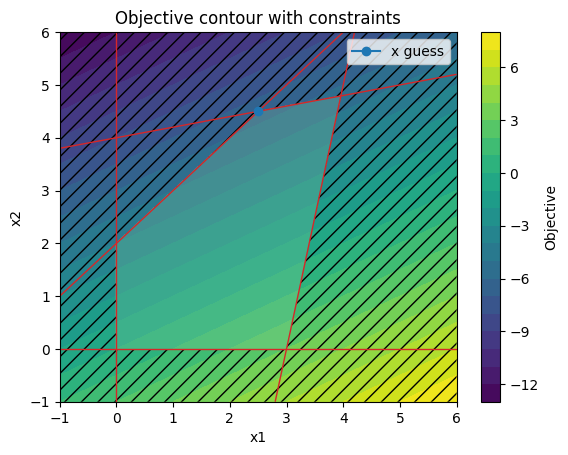

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Objective contour with constraints'}, xlabel='x1', ylabel='x2'>)

In [24]:
plotter = Plotter(objective=f1, constraints=constraints, x=np.array([5/2, 9/2]))

plotter.plot_contour(
    xlim=(-1, 6),
    ylim=(-1, 6),
    grid_size=400,  # increase if you want smoother contours
)

## Problem 3

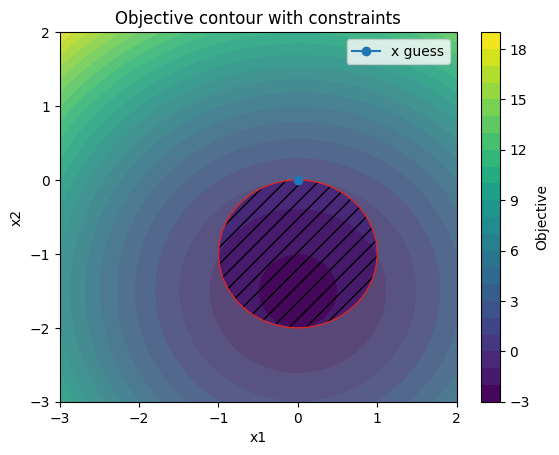

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'Objective contour with constraints'}, xlabel='x1', ylabel='x2'>)

In [ ]:
def f3(x): 
    return x[0]**2 + x[1]**2 + 3*x[1] 

constraints = [lambda x: x[0]**2 + (x[1] + 1)**2 - 1]  

plotter = Plotter(objective=f3, constraints=constraints, x=np.array([0, 0]))



plotter.plot_contour(
    xlim=(-3, 2),
    ylim=(-3, 2),
    grid_size=400,  # increase if you want smoother contours
)

We plot it as a function of $x_2$

$$
x_1^2 + (x_2 + 1)^2 - 1 = 0
$$

$$
\Leftrightarrow x_1^2 + x_2^2 + 2x_2 = 0
$$

$$
\Leftrightarrow x_1^2 = -x_2^2  - 2x_2 
$$

The function now becomes

$$
f_n(x) = -x_2^2 - 2x_2 + x_2^2 + 3x_2 
$$

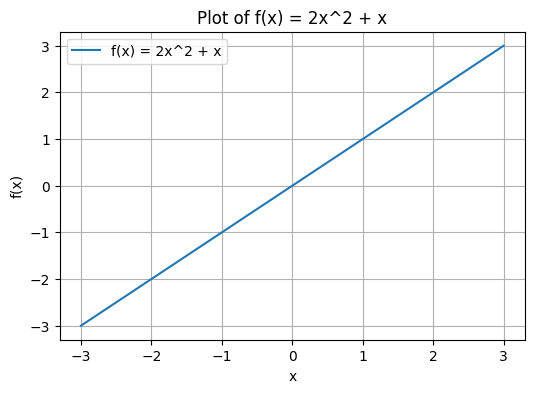

In [30]:
def fn(x): 
    return x 


x = np.linspace(-3, 3, 100) 
y = fn(x) 

plt.figure(figsize=(6, 4))
plt.plot(x, y, label='f(x) = 2x^2 + x') 
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of f(x) = 2x^2 + x')
plt.legend()
plt.grid()
plt.show()

PROOFS

1. 

$$
\nabla f = 
\begin{bmatrix} 
2x_1 \\ 
2x_2 + 3
\end{bmatrix}
$$

and 

$$
\nabla c(x) = 
\begin{bmatrix}
2x_1 \\ 
2x_2 + 2 
\end{bmatrix}
$$

We see that at 
$$
\bold{x} = (0,0) 
$$

The constraints is indeed 0 as
$$
c(x) = 1^2 - 1 = 0 
$$

and that 



$$
\nabla f - \lambda \nabla c(x)  = 
\begin{bmatrix} 
2x_1 \\ 
2x_2 + 3
\end{bmatrix}
-
\lambda
\begin{bmatrix}
2x_1 \\ 
2x_2 + 2 
\end{bmatrix}
=
\begin{bmatrix} 
0 \\ 
 3
\end{bmatrix}
-
\lambda
\begin{bmatrix}
0 \\ 
 2 
\end{bmatrix}
= 0
$$ 


which is indeed feasble 

2. 
From above its clear that its positive

3. 


In [31]:
x1, x2 = sp.symbols('x1 x2') 
f = x1**2 + x2**2 + 3*x2 

H = sp.hessian(f, (x1, x2)) 
H

Matrix([
[2, 0],
[0, 2]])

BEcause the hessian is symmetric, its positive definite

4. 

From the contour plot and the objective function, its clear that is NOT a minimum. Otherwise we could prove this by taking a small step in each direction. 